## Notebook to extract HOMO & LUMO levels

**Created on 14th July, 2024; modified on 1st August, 2024**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Arial'
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.ipython_3d = True
import py3Dmol
from pymatgen.io.gaussian import Molecule, GaussianInput, GaussianOutput
from pymatgen.io.xyz import XYZ
import glob
import os, sys
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, Descriptors, rdMolDescriptors, PandasTools

In [3]:
%%bash
pwd
ls -ltr

/Users/riteshk/Library/CloudStorage/Box-Box/Research-postdoc/eScore-extension/gaussian-dft-calcs/optimization
total 1392
-rw-r--r--   1 riteshk  staff     620 Jul 10 16:21 bind_energy_Li_first.csv
-rw-r--r--   1 riteshk  staff     880 Jul 11 14:51 third_Li_bind_energy.csv


-rw-r--r--@  1 riteshk  staff   26870 Jul 12 09:59 plot_bind_energy_Li_07122024.pdf
-rw-r--r--@  1 riteshk  staff     399 Jul 12 11:43 bind_energy_Li_all.csv
-rw-r--r--@  1 riteshk  staff   30240 Jul 12 11:48 plot_bind_energy_Li_vs_CE_07122024.pdf
drwx------   8 riteshk  staff     256 Jul 14 18:12 LiFSA
-rw-r--r--@  1 riteshk  staff    2016 Aug  5 14:47 frontier_isolated_solv_add_080524.csv
drwx------   4 riteshk  staff     128 Aug  5 14:49 FSA-
-rw-r--r--   1 riteshk  staff    1137 Aug  5 14:52 frontier_isolated_solv_all_080124.csv
-rw-r--r--@  1 riteshk  staff     821 Aug  5 15:00 frontier_isolated_solv_080124.csv
-rw-r--r--@  1 riteshk  staff     805 Aug  5 15:01 frontier_isolated_solv_080524.csv
drwxr-xr-x  13 riteshk  staff     416 Aug  5 15:03 isolated-solv
-rw-r--r--@  1 riteshk  staff    3822 Aug  5 15:33 frontier_isolated_solv_all_080524.csv
-rw-r--r--@  1 riteshk  staff    2865 Aug  5 15:48 lumo_vs_ce_isolated_080524.csv
-rw-r--r--@  1 riteshk  staff    1284 Aug  5 16:03 ood_

### System: isolated solvents

#### For first iteration molecules

In [3]:
os.chdir('/Users/riteshk/Library/CloudStorage/Box-Box/Research-postdoc/eScore-extension/gaussian-dft-calcs/optimization/isolated-solv/1st-iter/') ## MBP path
log_list_1 = glob.glob("*.log")
log_list_1

['first_4.log',
 'first_5.log',
 'first_1.log',
 'first_0.log',
 'first_2.log',
 'first_3.log']

In [4]:
# done_list = [i if GaussianOutput(log[i]).properly_terminated == True else continue for in range(log_list)]
done_list_1 = [i for i in log_list_1 if GaussianOutput(i).properly_terminated == True]
done_list_1

['first_4.log',
 'first_5.log',
 'first_1.log',
 'first_0.log',
 'first_2.log',
 'first_3.log']

In [5]:
pym_mol_list_1 = [Molecule.from_file(i) for i in done_list_1]
pym_mol_list_1[0]

Molecule Summary
Site: C (2.2372, 0.7244, 0.0981)
Site: C (1.3699, -0.2035, -0.7311)
Site: S (-0.2264, -0.5775, 0.0525)
Site: O (-1.0096, -1.4564, -0.8021)
Site: O (-0.0506, -0.8811, 1.4644)
Site: Cl (-1.1680, 1.3502, -0.0382)
Site: H (2.4516, 0.2980, 1.0777)
Site: H (1.7718, 1.7019, 0.2251)
Site: H (3.1817, 0.8635, -0.4315)
Site: H (1.1075, 0.1951, -1.7107)
Site: H (1.8041, -1.1991, -0.8512)

In [22]:
path = '/Users/riteshk/Library/CloudStorage/Box-Box/Research-postdoc/eScore-extension/gaussian-dft-calcs/optimization/isolated-solv/'
df_list_mol_1 = pd.read_csv(path + 'list_1st_iter.csv')
df_list_mol_1

,smiles,CAS,CE_1M,CE_2M,dissolve,dual_phase
0,COCCOS(=O)(=O)C(F)(F)F,112981-50-7,0.00,0.0,0,0
1,CCCCOCCCl,10503-96-5,14.83,NaN,1,0
2,CS(=O)(=O)OCCCF,372-04-3,97.75,NaN,1,0
3,CCOCCS(=O)(=O)Cl,69371-75-1,74.51,NaN,1,0
4,CCS(=O)(=O)Cl,594-44-5,31.61,NaN,1,0
5,C(CCl)S(=O)(=O)Cl,1622-32-8,6.29,NaN,0,1


In [6]:
homo_list_1 = []
lumo_list_1 = []
bandgap_list_1 = []
ctr_list_1 = []
for i in range(len(done_list_1)):
    energy_levels = GaussianOutput(done_list_1[i]).eigenvalues
    num_elecs = GaussianOutput(done_list_1[i]).electrons[0]
    ctr = done_list_1[i].split('_')[1].split('.')[0]
    ctr_list_1.append('first_'+str(ctr))
    homo = list(energy_levels.values())[0][num_elecs-1]; lumo = list(energy_levels.values())[0][num_elecs]; gap = lumo - homo
    homo *= 27.211324570273; lumo *= 27.211324570273; gap *= 27.211324570273 ## to convert units from au to eV
    print(ctr, homo, lumo, gap)
    homo_list_1.append(homo)
    lumo_list_1.append(lumo)
    bandgap_list_1.append(gap)

4 -8.97674386248736 -2.7020845298281086 6.274659332659252
5 -8.592247846309402 -2.8234470374115266 5.768800808897875
1 -7.373724732052578 -0.2968755510616784 7.0768491809909
0 -7.665702244691607 -0.48681059656218395 7.178891648129423
2 -8.481497755308393 -0.3583731445904954 8.123124610717896
3 -7.717403761375125 -2.76494268958544 4.952461071789685


In [7]:
energy_levels

{<Spin.up: 1>: [-101.57789,
  -89.10425,
  -19.16884,
  -19.16883,
  -19.14686,
  -10.2508,
  -10.24563,
  -10.22754,
  -10.16732,
  -9.49148,
  -8.16812,
  -7.25621,
  -7.24629,
  -7.24602,
  -6.13162,
  -6.12996,
  -6.12802,
  -1.16381,
  -1.05966,
  -1.0578,
  -0.8699,
  -0.8282,
  -0.76316,
  -0.69981,
  -0.63122,
  -0.61711,
  -0.5495,
  -0.52887,
  -0.52827,
  -0.50164,
  -0.4916,
  -0.48534,
  -0.44638,
  -0.42569,
  -0.411,
  -0.3908,
  -0.38751,
  -0.38536,
  -0.37439,
  -0.35929,
  -0.34998,
  -0.34733,
  -0.33595,
  -0.3327,
  -0.28361,
  -0.10161,
  -0.01414,
  0.00071,
  0.011,
  0.0135,
  0.02619,
  0.03044,
  0.03476,
  0.03978,
  0.04137,
  0.04603,
  0.05348,
  0.06023,
  0.06625,
  0.07124,
  0.07456,
  0.07923,
  0.09014,
  0.09321,
  0.10415,
  0.10637,
  0.11168,
  0.11859,
  0.12003,
  0.12411,
  0.12788,
  0.12861,
  0.13198,
  0.13624,
  0.14786,
  0.15279,
  0.1543,
  0.15692,
  0.1653,
  0.16684,
  0.16996,
  0.17486,
  0.18499,
  0.19286,
  0.2072,
  0.21478,

In [7]:
num_elecs

45

#### For second iteration molecules

In [8]:
os.chdir('/Users/riteshk/Library/CloudStorage/Box-Box/Research-postdoc/eScore-extension/gaussian-dft-calcs/optimization/isolated-solv/2nd-iter')
log_list_2 = glob.glob("*.log")
log_list_2

['second_3.log']

In [9]:
done_list_2 = [i for i in log_list_2 if GaussianOutput(i).properly_terminated == True]
done_list_2

['second_3.log']

In [10]:
pym_mol_list_2 = [Molecule.from_file(i) for i in done_list_2]
pym_mol_list_2[0]

Molecule Summary
Site: C (-5.0394, 0.1400, 0.2488)
Site: C (-3.7657, -0.6992, 0.1318)
Site: C (-2.5589, 0.1382, -0.3072)
Site: C (-1.3138, -0.7136, -0.4167)
Site: O (-0.1832, 0.0973, -0.9409)
Site: S (0.8538, 0.7837, 0.0559)
Site: O (1.4052, 1.9369, -0.6203)
Site: O (0.3288, 0.8563, 1.4072)
Site: C (2.2009, -0.5369, 0.0695)
Site: F (1.6855, -1.6891, 0.5023)
Site: F (2.6869, -0.7042, -1.1559)
Site: F (3.1762, -0.1528, 0.8885)
Site: H (-4.9147, 0.9416, 0.9825)
Site: H (-5.8873, -0.4736, 0.5627)
Site: H (-5.2949, 0.6010, -0.7098)
Site: H (-3.5486, -1.1729, 1.0955)
Site: H (-3.9255, -1.5117, -0.5856)
Site: H (-2.3830, 0.9418, 0.4139)
Site: H (-2.7586, 0.6039, -1.2769)
Site: H (-1.0214, -1.1440, 0.5403)
Site: H (-1.4091, -1.5051, -1.1576)

In [11]:
homo_list_2 = []
lumo_list_2 = []
bandgap_list_2 = []
ctr_list_2 = []
for i in range(len(done_list_2)):
    energy_levels = GaussianOutput(done_list_2[i]).eigenvalues
    num_elecs = GaussianOutput(done_list_2[i]).electrons[0]
    ctr = done_list_2[i].split('_')[1].split('.')[0]
    ctr_list_2.append('second_'+str(ctr))
    homo = list(energy_levels.values())[0][num_elecs-1]; lumo = list(energy_levels.values())[0][num_elecs]; gap = lumo - homo
    homo *= 27.211324570273; lumo *= 27.211324570273; gap *= 27.211324570273 ## to convert units from au to eV
    print(ctr, homo, lumo, gap)
    homo_list_2.append(homo)
    lumo_list_2.append(lumo)
    bandgap_list_2.append(gap)

3 -9.207223781597571 -0.31782827098078864 8.889395510616783


#### For third iteration molecules

In [12]:
os.chdir('/Users/riteshk/Library/CloudStorage/Box-Box/Research-postdoc/eScore-extension/gaussian-dft-calcs/optimization/isolated-solv/3rd-iter/') ## MBP path
log_list_3 = glob.glob("*.log")
log_list_3

['third_8.log',
 'third_3.log',
 'third_2.log',
 'third_0.log',
 'third_1.log',
 'third_5.log',
 'third_4.log',
 'third_6.log',
 'third_7.log']

In [13]:
done_list_3 = [i for i in log_list_3 if GaussianOutput(i).properly_terminated == True]
done_list_3

['third_8.log',
 'third_3.log',
 'third_2.log',
 'third_0.log',
 'third_1.log',
 'third_5.log',
 'third_4.log',
 'third_6.log',
 'third_7.log']

In [14]:
homo_list_3 = []
lumo_list_3 = []
bandgap_list_3 = []
ctr_list_3 = []
for i in range(len(done_list_3)):
    energy_levels = GaussianOutput(done_list_3[i]).eigenvalues
    num_elecs = GaussianOutput(done_list_3[i]).electrons[0]
    ctr = done_list_3[i].split('_')[1].split('.')[0]
    ctr_list_3.append('third_'+str(ctr))
    homo = list(energy_levels.values())[0][num_elecs-1]; lumo = list(energy_levels.values())[0][num_elecs]; gap = lumo - homo
    homo *= 27.211324570273; lumo *= 27.211324570273; gap *= 27.211324570273 ## to convert units from au to eV
    print(ctr, homo, lumo, gap)
    homo_list_3.append(homo)
    lumo_list_3.append(lumo)
    bandgap_list_3.append(gap)

8 -7.344336501516682 -0.15211130434782608 7.192225197168856
3 -7.049637856420627 -0.2068060667340748 6.842831789686552
2 -7.1285506976744175 -0.16979866531850352 6.958752032355913
0 -7.485835389282102 -0.19456097067745196 7.291274418604651
1 -7.981353609706774 -0.39075462082912027 7.590598988877654
5 -7.940808736097067 -0.136056622851365 7.804752113245702
4 -9.389811769464103 -0.08517144590495448 9.304640323559148
6 -7.162292740141556 -0.16898232558139534 6.9933104145601614
7 -7.861895894843276 -2.5834431547017185 5.278452740141557


#### For FSA-

In [15]:
os.chdir('/Users/riteshk/Library/CloudStorage/Box-Box/Research-postdoc/eScore-extension/gaussian-dft-calcs/optimization/FSA-/') ## MBP path
log_list_4 = glob.glob("*.log")
log_list_4

['fsa-.log']

In [16]:
done_list_4 = [i for i in log_list_4 if GaussianOutput(i).properly_terminated == True]
done_list_4

['fsa-.log']

In [17]:
homo_list_4 = []
lumo_list_4 = []
bandgap_list_4 = []
ctr_list_4 = []
for i in range(len(done_list_4)):
    energy_levels = GaussianOutput(done_list_4[i]).eigenvalues
    num_elecs = GaussianOutput(done_list_4[i]).electrons[0]
    # ctr = done_list_4[i].split('_')[1].split('.')[0]
    ctr = 0
    ctr_list_4.append('fsa')
    homo = list(energy_levels.values())[0][num_elecs-1]; lumo = list(energy_levels.values())[0][num_elecs]; gap = lumo - homo
    homo *= 27.211324570273; lumo *= 27.211324570273; gap *= 27.211324570273 ## to convert units from au to eV
    print(ctr, homo, lumo, gap)
    homo_list_4.append(homo)
    lumo_list_4.append(lumo)
    bandgap_list_4.append(gap)

0 -8.036320485338724 -0.3284406875631951 7.7078797977755285


In [18]:
homo_all = homo_list_1 + homo_list_2 + homo_list_3 + homo_list_4
lumo_all = lumo_list_1 + lumo_list_2 + lumo_list_3 + lumo_list_4
bandgap_all = bandgap_list_1 + bandgap_list_2 + bandgap_list_3 + bandgap_list_4
ctr_all = ctr_list_1 + ctr_list_2 + ctr_list_3 + ctr_list_4

dict_frontier = {'Compound_id': ctr_all, 'HOMO': homo_all, 'LUMO': lumo_all, 'Bandgap': bandgap_all}
dict_frontier

{'Compound_id': ['first_4',
  'first_5',
  'first_1',
  'first_0',
  'first_2',
  'first_3',
  'second_3',
  'third_8',
  'third_3',
  'third_2',
  'third_0',
  'third_1',
  'third_5',
  'third_4',
  'third_6',
  'third_7',
  'fsa'],
 'HOMO': [-8.97674386248736,
  -8.592247846309402,
  -7.373724732052578,
  -7.665702244691607,
  -8.481497755308393,
  -7.717403761375125,
  -9.207223781597571,
  -7.344336501516682,
  -7.049637856420627,
  -7.1285506976744175,
  -7.485835389282102,
  -7.981353609706774,
  -7.940808736097067,
  -9.389811769464103,
  -7.162292740141556,
  -7.861895894843276,
  -8.036320485338724],
 'LUMO': [-2.7020845298281086,
  -2.8234470374115266,
  -0.2968755510616784,
  -0.48681059656218395,
  -0.3583731445904954,
  -2.76494268958544,
  -0.31782827098078864,
  -0.15211130434782608,
  -0.2068060667340748,
  -0.16979866531850352,
  -0.19456097067745196,
  -0.39075462082912027,
  -0.136056622851365,
  -0.08517144590495448,
  -0.16898232558139534,
  -2.5834431547017185,
  

In [19]:
df_frontier = pd.DataFrame(dict_frontier)
df_frontier

,Compound_id,HOMO,LUMO,Bandgap
0,first_4,-8.976744,-2.702085,6.274659
1,first_5,-8.592248,-2.823447,5.768801
2,first_1,-7.373725,-0.296876,7.076849
3,first_0,-7.665702,-0.486811,7.178892
4,first_2,-8.481498,-0.358373,8.123125
5,first_3,-7.717404,-2.764943,4.952461
6,second_3,-9.207224,-0.317828,8.889396
7,third_8,-7.344337,-0.152111,7.192225
8,third_3,-7.049638,-0.206806,6.842832
9,third_2,-7.128551,-0.169799,6.958752


In [20]:
df_frontier.to_csv('frontier_isolated_solv_080124.csv', index=False)

In [38]:
os.chdir('/Users/riteshk/Library/CloudStorage/Box-Box/Research-postdoc/eScore-extension/gaussian-dft-calcs/optimization')
df_frontier = pd.read_csv('frontier_isolated_solv_080124.csv')
df_frontier

,Compound_id,HOMO,LUMO,Bandgap
0,first_4,-8.976744,-2.702085,6.274659
1,first_5,-8.592248,-2.823447,5.768801
2,first_1,-7.373725,-0.296876,7.076849
3,first_0,-7.665702,-0.486811,7.178892
4,first_2,-8.481498,-0.358373,8.123125
5,first_3,-7.717404,-2.764943,4.952461
6,second_3,-9.207224,-0.317828,8.889396
7,third_8,-7.344337,-0.152111,7.192225
8,third_3,-7.049638,-0.206806,6.842832
9,third_2,-7.128551,-0.169799,6.958752


In [39]:
df_frontier['numeric_part'] = df_frontier['Compound_id'].str.extract('(\d+)').astype(int)
df_frontier['prefix'] = df_frontier['Compound_id'].apply(lambda x: 0 if x.startswith('first_') else (1 if x.startswith('second_') else (2 if x.startswith('third_') else 3)))
df_frontier = df_frontier.sort_values(by=['prefix', 'numeric_part'])
df_frontier = df_frontier.drop(columns=['numeric_part', 'prefix'])
df_frontier

,Compound_id,HOMO,LUMO,Bandgap
3,first_0,-7.665702,-0.486811,7.178892
2,first_1,-7.373725,-0.296876,7.076849
4,first_2,-8.481498,-0.358373,8.123125
5,first_3,-7.717404,-2.764943,4.952461
0,first_4,-8.976744,-2.702085,6.274659
1,first_5,-8.592248,-2.823447,5.768801
6,second_3,-9.207224,-0.317828,8.889396
10,third_0,-7.485835,-0.194561,7.291274
11,third_1,-7.981354,-0.390755,7.590599
9,third_2,-7.128551,-0.169799,6.958752


In [40]:
df_frontier.to_csv('frontier_isolated_solv_080524.csv', index=False)

#### For OOD molecules from electrolytomics work

In [14]:
os.chdir('/Users/riteshk/Library/CloudStorage/Box-Box/Research-postdoc/eScore-extension/gaussian-dft-calcs/optimization/isolated-solv/lit-in-house/')
log_list_5 = glob.glob("*.log")
log_list_5

['ood_2.log',
 'ood_3.log',
 'ood_1.log',
 'ood_0.log',
 'ood_4.log',
 'ood_5.log',
 'ood_7.log',
 'ood_6.log',
 'ood_17.log',
 'ood_16.log',
 'ood_14.log',
 'ood_15.log',
 'ood_11.log',
 'ood_10.log',
 'ood_22.log',
 'ood_23.log',
 'ood_20.log',
 'ood_24.log',
 'ood_18.log',
 'ood_19.log',
 'ood_25.log',
 'ood_8.log',
 'ood_9.log']

In [15]:
done_list_5 = [i for i in log_list_5 if GaussianOutput(i).properly_terminated == True]
done_list_5

['ood_2.log',
 'ood_3.log',
 'ood_1.log',
 'ood_0.log',
 'ood_4.log',
 'ood_5.log',
 'ood_7.log',
 'ood_6.log',
 'ood_17.log',
 'ood_16.log',
 'ood_14.log',
 'ood_15.log',
 'ood_11.log',
 'ood_10.log',
 'ood_22.log',
 'ood_23.log',
 'ood_20.log',
 'ood_24.log',
 'ood_18.log',
 'ood_19.log',
 'ood_25.log',
 'ood_8.log',
 'ood_9.log']

In [16]:
homo_list_5 = []
lumo_list_5 = []
bandgap_list_5 = []
ctr_list_5 = []
for i in range(len(done_list_5)):
    energy_levels = GaussianOutput(done_list_5[i]).eigenvalues
    num_elecs = GaussianOutput(done_list_5[i]).electrons[0]
    ctr = done_list_5[i].split('_')[1].split('.')[0]
    ctr_list_5.append('ood_'+str(ctr))
    homo = list(energy_levels.values())[0][num_elecs-1]; lumo = list(energy_levels.values())[0][num_elecs]; gap = lumo - homo
    homo *= 27.211324570273; lumo *= 27.211324570273; gap *= 27.211324570273 ## to convert units from au to eV
    print(ctr, homo, lumo, gap)
    homo_list_5.append(homo)
    lumo_list_5.append(lumo)
    bandgap_list_5.append(gap)

2 -7.540530151668351 -0.19700998988877652 7.3435201617795745
3 -6.87956707785642 -0.18830236602628916 6.69126471183013
1 -7.096713447927198 -0.19619365015166834 6.900519797775529
0 -7.542979170879676 -0.21034353892821028 7.332635631951465
4 -7.072495369059655 -0.2266703336703741 6.84582503538928
5 -7.184061799797775 -0.13768930232558138 7.046372497472194
7 -7.112223902932254 -0.20544550050556115 6.906778402426693
6 -7.088005824064711 -0.16490062689585439 6.923105197168856
17 -7.571823174924165 -0.14394790697674417 7.427875267947421
16 -7.0338552881698675 -0.14285945399393327 6.890995834175935
14 -8.02897342770475 -0.17251979777553084 7.85645362992922
15 -7.660532093023255 -0.15456032355915064 7.505971769464104
11 -7.866249706774519 -0.15183919110212332 7.714410515672396
10 -6.928003235591506 -0.28463045500505557 6.64337278058645
22 -6.874396926188068 -0.1616352679474216 6.712761658240647
23 -7.02106596562184 -0.1730640242669363 6.848001941354904
20 -7.806384792719919 -0.300957249747219

#### For experimentally tested molecules from electrolytomics work & SOTA

In [26]:
os.chdir('/Users/riteshk/Library/CloudStorage/Box-Box/Research-postdoc/eScore-extension/gaussian-dft-calcs/optimization/isolated-solv/sota_expt_omics/')
log_list_6 = glob.glob("*.log")
log_list_6

['sota_2.log',
 'sota_0.log',
 'sota_5.log',
 'sota_4.log',
 'sota_7.log',
 'sota_10.log',
 'sota_9.log',
 'sota_8.log']

In [27]:
done_list_6 = [i for i in log_list_6 if GaussianOutput(i).properly_terminated == True]
done_list_6

['sota_2.log',
 'sota_0.log',
 'sota_5.log',
 'sota_4.log',
 'sota_7.log',
 'sota_10.log',
 'sota_9.log',
 'sota_8.log']

In [28]:
homo_list_6 = []
lumo_list_6 = []
bandgap_list_6 = []
ctr_list_6 = []
for i in range(len(done_list_6)):
    energy_levels = GaussianOutput(done_list_6[i]).eigenvalues
    num_elecs = GaussianOutput(done_list_6[i]).electrons[0]
    ctr = done_list_6[i].split('_')[1].split('.')[0]
    ctr_list_6.append('sota_'+str(ctr))
    homo = list(energy_levels.values())[0][num_elecs-1]; lumo = list(energy_levels.values())[0][num_elecs]; gap = lumo - homo
    homo *= 27.211324570273; lumo *= 27.211324570273; gap *= 27.211324570273 ## to convert units from au to eV
    print(ctr, homo, lumo, gap)
    homo_list_6.append(homo)
    lumo_list_6.append(lumo)
    bandgap_list_6.append(gap)

2 -7.590598988877653 -0.8215098887765419 6.769089100101111
0 -5.922544792719918 -0.22803089989888775 5.694513892821031
5 -9.494575369059655 -0.8288569464105155 8.66571842264914
4 -9.165862568250757 -2.3943244489383213 6.771538119312435
7 -7.681484812942364 -0.2070781799797775 7.474406632962587
10 -6.947595389282102 -0.12027405460060667 6.827321334681496
9 -7.78869743174924 -0.15374398382204243 7.634953447927198
8 -7.762030333670373 -0.08925314459049544 7.672777189079878


In [29]:
homo_add = homo_list_5 + homo_list_6
lumo_add = lumo_list_5 + lumo_list_6
bandgap_add = bandgap_list_5 + bandgap_list_6
ctr_add = ctr_list_5 + ctr_list_6

dict_frontier_add = {'Compound_id': ctr_add, 'HOMO': homo_add, 'LUMO': lumo_add, 'Bandgap': bandgap_add}
df_frontier_add = pd.DataFrame(dict_frontier_add)
df_frontier_add

,Compound_id,HOMO,LUMO,Bandgap
0,ood_2,-7.540530,-0.197010,7.343520
1,ood_3,-6.879567,-0.188302,6.691265
2,ood_1,-7.096713,-0.196194,6.900520
3,ood_0,-7.542979,-0.210344,7.332636
4,ood_4,-7.072495,-0.226670,6.845825
5,ood_5,-7.184062,-0.137689,7.046372
6,ood_7,-7.112224,-0.205446,6.906778
7,ood_6,-7.088006,-0.164901,6.923105
8,ood_17,-7.571823,-0.143948,7.427875
9,ood_16,-7.033855,-0.142859,6.890996


In [30]:
# Extract numerical part and convert to integer
df_frontier_add['numeric_part'] = df_frontier_add['Compound_id'].str.extract('(\d+)').astype(int)

# Create a sorting key for the prefix
df_frontier_add['prefix'] = df_frontier_add['Compound_id'].apply(lambda x: 0 if x.startswith('ood_') else 1)

# Sort by the prefix and then by the numeric part
df_frontier_add = df_frontier_add.sort_values(by=['prefix', 'numeric_part'])

# Drop the helper columns if no longer needed
df_frontier_add = df_frontier_add.drop(columns=['numeric_part', 'prefix'])
df_frontier_add

,Compound_id,HOMO,LUMO,Bandgap
3,ood_0,-7.542979,-0.210344,7.332636
2,ood_1,-7.096713,-0.196194,6.900520
0,ood_2,-7.540530,-0.197010,7.343520
1,ood_3,-6.879567,-0.188302,6.691265
4,ood_4,-7.072495,-0.226670,6.845825
5,ood_5,-7.184062,-0.137689,7.046372
7,ood_6,-7.088006,-0.164901,6.923105
6,ood_7,-7.112224,-0.205446,6.906778
21,ood_8,-7.730465,-0.260957,7.469509
22,ood_9,-7.643933,-0.255786,7.388147


In [31]:
df_frontier_add.to_csv('frontier_isolated_solv_add_080524.csv', index=False)

#### Plot LUMO vs CE for all

In [59]:
df_lumo_all = pd.read_csv('frontier_isolated_solv_all_080524.csv')
df_lumo_all

,Compound_id,smiles,HOMO,LUMO,Bandgap,CE,salt_conc,dissolve,database,database_
0,first_0,COCCOS(=O)(=O)C(F)(F)F,-7.665702,-0.486811,7.178892,0.000000,1.0,0.0,this_work,0
1,first_1,CCCCOCCCl,-7.373725,-0.296876,7.076849,0.148300,1.0,1.0,this_work,0
2,first_2,CS(=O)(=O)OCCCF,-8.481498,-0.358373,8.123125,0.977500,1.0,1.0,this_work,0
3,first_3,CCOCCS(=O)(=O)Cl,-7.717404,-2.764943,4.952461,0.745100,1.0,1.0,this_work,0
4,first_4,CCS(=O)(=O)Cl,-8.976744,-2.702085,6.274659,0.316100,1.0,1.0,this_work,0
5,first_5,C(CCl)S(=O)(=O)Cl,-8.592248,-2.823447,5.768801,0.062900,1.0,1.0,this_work,0
6,second_3,CCCCOS(=O)(=O)C(F)(F)F,-9.207224,-0.317828,8.889396,0.000000,1.0,0.0,this_work,0
7,third_0,CC1(OCC(O1)CF)C,-7.485835,-0.194561,7.291274,0.952400,1.0,1.0,this_work,0
8,third_1,FC(COC(=O)C(C)(C)C)F,-7.981354,-0.390755,7.590599,0.781800,1.0,1.0,this_work,0
9,third_2,CCOCC(C)C,-7.128551,-0.169799,6.958752,0.988400,2.0,1.0,this_work,0


In [60]:
df_1 = df_lumo_all.loc[df_lumo_all['dissolve'] == 1.0]
df_1

,Compound_id,smiles,HOMO,LUMO,Bandgap,CE,salt_conc,dissolve,database,database_
1,first_1,CCCCOCCCl,-7.373725,-0.296876,7.076849,0.148300,1.0,1.0,this_work,0
2,first_2,CS(=O)(=O)OCCCF,-8.481498,-0.358373,8.123125,0.977500,1.0,1.0,this_work,0
3,first_3,CCOCCS(=O)(=O)Cl,-7.717404,-2.764943,4.952461,0.745100,1.0,1.0,this_work,0
4,first_4,CCS(=O)(=O)Cl,-8.976744,-2.702085,6.274659,0.316100,1.0,1.0,this_work,0
5,first_5,C(CCl)S(=O)(=O)Cl,-8.592248,-2.823447,5.768801,0.062900,1.0,1.0,this_work,0
7,third_0,CC1(OCC(O1)CF)C,-7.485835,-0.194561,7.291274,0.952400,1.0,1.0,this_work,0
8,third_1,FC(COC(=O)C(C)(C)C)F,-7.981354,-0.390755,7.590599,0.781800,1.0,1.0,this_work,0
9,third_2,CCOCC(C)C,-7.128551,-0.169799,6.958752,0.988400,2.0,1.0,this_work,0
10,third_3,CC(C)COCC(C)C,-7.049638,-0.206806,6.842832,NaN,1.0,1.0,this_work,0
15,third_8,CCCC(OC)OC,-7.344337,-0.152111,7.192225,0.886900,1.0,1.0,this_work,0


In [61]:
df_1_uniq = df_1.drop_duplicates(subset='smiles', keep='first')
df_1_uniq

,Compound_id,smiles,HOMO,LUMO,Bandgap,CE,salt_conc,dissolve,database,database_
1,first_1,CCCCOCCCl,-7.373725,-0.296876,7.076849,0.148300,1.0,1.0,this_work,0
2,first_2,CS(=O)(=O)OCCCF,-8.481498,-0.358373,8.123125,0.977500,1.0,1.0,this_work,0
3,first_3,CCOCCS(=O)(=O)Cl,-7.717404,-2.764943,4.952461,0.745100,1.0,1.0,this_work,0
4,first_4,CCS(=O)(=O)Cl,-8.976744,-2.702085,6.274659,0.316100,1.0,1.0,this_work,0
5,first_5,C(CCl)S(=O)(=O)Cl,-8.592248,-2.823447,5.768801,0.062900,1.0,1.0,this_work,0
7,third_0,CC1(OCC(O1)CF)C,-7.485835,-0.194561,7.291274,0.952400,1.0,1.0,this_work,0
8,third_1,FC(COC(=O)C(C)(C)C)F,-7.981354,-0.390755,7.590599,0.781800,1.0,1.0,this_work,0
9,third_2,CCOCC(C)C,-7.128551,-0.169799,6.958752,0.988400,2.0,1.0,this_work,0
10,third_3,CC(C)COCC(C)C,-7.049638,-0.206806,6.842832,NaN,1.0,1.0,this_work,0
15,third_8,CCCC(OC)OC,-7.344337,-0.152111,7.192225,0.886900,1.0,1.0,this_work,0


In [62]:
df_1_uniq.drop(index=[10], inplace=True)
df_1_uniq.reset_index(drop=True, inplace=True)
df_1_uniq

/var/folders/s5/lmr5dh0n4bsgnpxrzwlts5lw0000gn/T/ipykernel_31577/3130366628.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_1_uniq.drop(index=[10], inplace=True)


,Compound_id,smiles,HOMO,LUMO,Bandgap,CE,salt_conc,dissolve,database,database_
0,first_1,CCCCOCCCl,-7.373725,-0.296876,7.076849,0.148300,1.0,1.0,this_work,0
1,first_2,CS(=O)(=O)OCCCF,-8.481498,-0.358373,8.123125,0.977500,1.0,1.0,this_work,0
2,first_3,CCOCCS(=O)(=O)Cl,-7.717404,-2.764943,4.952461,0.745100,1.0,1.0,this_work,0
3,first_4,CCS(=O)(=O)Cl,-8.976744,-2.702085,6.274659,0.316100,1.0,1.0,this_work,0
4,first_5,C(CCl)S(=O)(=O)Cl,-8.592248,-2.823447,5.768801,0.062900,1.0,1.0,this_work,0
5,third_0,CC1(OCC(O1)CF)C,-7.485835,-0.194561,7.291274,0.952400,1.0,1.0,this_work,0
6,third_1,FC(COC(=O)C(C)(C)C)F,-7.981354,-0.390755,7.590599,0.781800,1.0,1.0,this_work,0
7,third_2,CCOCC(C)C,-7.128551,-0.169799,6.958752,0.988400,2.0,1.0,this_work,0
8,third_8,CCCC(OC)OC,-7.344337,-0.152111,7.192225,0.886900,1.0,1.0,this_work,0
9,ood_0,FC(F)(F)COCCOCCOCC(F)(F)F,NaN,-0.210344,0.991411,0.991411,1.0,1.0,ood,2


In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
plt.scatter(df_1_uniq['LUMO'], df_1_uniq['CE'])

In [63]:
blue = (0, 0.576, 0.902) # 0, 147, 230
green = (0.349,0.745,0.306) # 89, 190, 78
red = (0.984, 0.262, 0.219) # 251, 67, 56 
orange = (0.984, 0.713, 0.305) # 251, 182, 78 
purple = (0.839, 0.286, 0.604) # 214, 73, 1541
anvil = (0.298, 0.78, 0.77) # 76, 199, 196
dark_purple = (0.557, 0, 0.998) # 142, 0, 252
pink = (0.95, 0.78, 0.996) # 242, 199, 154
gray = (0.463,0.463,0.463) # 118, 118, 118
colors = [blue, orange, purple, anvil]

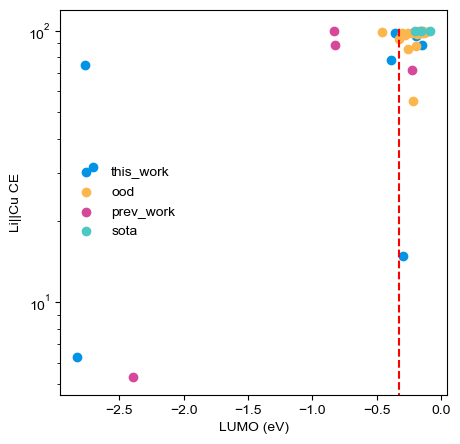

In [78]:
# Get unique values from the 'database' column
unique_databases = df_1_uniq['database'].unique()

fig, ax = plt.subplots(figsize=(5, 5))
# Loop through each unique value and create a scatter plot
c = 0
for database in unique_databases:
    subset = df_1_uniq[df_1_uniq['database'] == database]
    ax.scatter(subset['LUMO'], 100*subset['CE'], label=database, color=colors[c])  # Replace 'x_column' and 'y_column' with actual column names
    c += 1
# plt.title(f'Scatter Plot for {database}')
ax.vlines(x=-0.328441, ymin=0, ymax=103, color='red', linestyle='--')
ax.set_xlabel('LUMO (eV)')  # Replace with actual label
ax.set_ylabel('Li||Cu CE')  # Replace with actual label
# ax.set_ylim(0, 103)
ax.set_yscale('log')
plt.legend(frameon=False, loc='center left')
plt.show()

In [76]:
# df_1_uniq.to_csv('lumo_vs_ce_isolated_080524.csv', index=False)
df_1_uniq.to_csv('lumo_vs_ce_isolated_080524.csv', index=False)

### System: Li-bound solvent complexes

In [35]:
os.chdir('/Users/riteshk/Library/CloudStorage/Box-Box/Research-postdoc/eScore-extension/gaussian-dft-calcs/optimization/')
df_bind_all = pd.read_csv('lumo_bind_vs_ce_class_081424.csv')
df_bind_all

,Compound_id,min_config,smiles,HOMO_iso,LUMO_iso,Bandgap_iso,CE,salt_conc,dissolve,database,database_,bind_ener_eV,class
0,first_1,1,CCCCOCCCl,-7.373725,-0.296876,7.076849,0.148300,1.0,1.0,this_work,0,-0.503419,Ether
1,first_2,1,CS(=O)(=O)OCCCF,-8.481498,-0.358373,8.123125,0.977500,1.0,1.0,this_work,0,-0.382570,Sulfonate ester
2,first_3,1,CCOCCS(=O)(=O)Cl,-7.717404,-2.764943,4.952461,0.745100,1.0,1.0,this_work,0,-0.266541,Sulfonyl chloride
3,first_4,1,CCS(=O)(=O)Cl,-8.976744,-2.702085,6.274659,0.316100,1.0,1.0,this_work,0,-0.275491,Sulfonyl chloride
4,first_5,1,C(CCl)S(=O)(=O)Cl,-8.592248,-2.823447,5.768801,0.062900,1.0,1.0,this_work,0,-0.260382,Sulfonyl chloride
5,third_0,2,CC1(OCC(O1)CF)C,-7.485835,-0.194561,7.291274,0.952400,1.0,1.0,this_work,0,-0.392002,Ether
6,third_1,1,FC(COC(=O)C(C)(C)C)F,-7.981354,-0.390755,7.590599,0.781800,1.0,1.0,this_work,0,-0.373306,Ester
7,third_2,1,CCOCC(C)C,-7.128551,-0.169799,6.958752,0.988400,2.0,1.0,this_work,0,-0.368000,Ether
8,third_8,1,CCCC(OC)OC,-7.344337,-0.152111,7.192225,0.886900,1.0,1.0,this_work,0,-0.482776,Ether
9,ood_0,1,FC(F)(F)COCCOCCOCC(F)(F)F,NaN,-0.210344,0.991411,0.991411,1.0,1.0,ood,2,-0.914360,Ether


#### For first iteration molecules

In [7]:
df_bind_1 = df_bind_all.loc[df_bind_all['Compound_id'].str.startswith('first')]
df_bind_1

,Compound_id,min_config,smiles,HOMO_iso,LUMO_iso,Bandgap_iso,CE,salt_conc,dissolve,database,database_,bind_ener_eV,class
0,first_1,1,CCCCOCCCl,-7.373725,-0.296876,7.076849,0.1483,1.0,1.0,this_work,0,-0.503419,Ether
1,first_2,1,CS(=O)(=O)OCCCF,-8.481498,-0.358373,8.123125,0.9775,1.0,1.0,this_work,0,-0.382570,Sulfonate ester
2,first_3,1,CCOCCS(=O)(=O)Cl,-7.717404,-2.764943,4.952461,0.7451,1.0,1.0,this_work,0,-0.266541,Sulfonyl chloride
3,first_4,1,CCS(=O)(=O)Cl,-8.976744,-2.702085,6.274659,0.3161,1.0,1.0,this_work,0,-0.275491,Sulfonyl chloride
4,first_5,1,C(CCl)S(=O)(=O)Cl,-8.592248,-2.823447,5.768801,0.0629,1.0,1.0,this_work,0,-0.260382,Sulfonyl chloride


In [15]:
os.chdir('/Users/riteshk/Library/CloudStorage/Box-Box/Research-postdoc/eScore-extension/gaussian-dft-calcs/optimization/Li-bound/1st-iter/') ## MBP path
# log_list_1 = df_bind_1['Compound_id'].to_list() + '_Li+_' + str(df_bind_1['min_config'].to_list()) + '.log'
log_list_1 = [f"{compound_id}_Li+_{min_config}.log" for compound_id, min_config in zip(df_bind_1['Compound_id'], df_bind_1['min_config'])]
log_list_1

['first_1_Li+_1.log',
 'first_2_Li+_1.log',
 'first_3_Li+_1.log',
 'first_4_Li+_1.log',
 'first_5_Li+_1.log']

In [16]:
done_list_1 = [i for i in log_list_1 if GaussianOutput(i).properly_terminated == True]
done_list_1

['first_1_Li+_1.log',
 'first_2_Li+_1.log',
 'first_3_Li+_1.log',
 'first_4_Li+_1.log',
 'first_5_Li+_1.log']

In [17]:
homo_list_1 = []
lumo_list_1 = []
bandgap_list_1 = []
ctr_list_1 = []
for i in range(len(done_list_1)):
    energy_levels = GaussianOutput(done_list_1[i]).eigenvalues
    num_elecs = GaussianOutput(done_list_1[i]).electrons[0]
    ctr = done_list_1[i].split('_')[1].split('.')[0]
    ctr_list_1.append('first_'+str(ctr))
    homo = list(energy_levels.values())[0][num_elecs-1]; lumo = list(energy_levels.values())[0][num_elecs]; gap = lumo - homo
    homo *= 27.211324570273; lumo *= 27.211324570273; gap *= 27.211324570273 ## to convert units from au to eV
    print(ctr, homo, lumo, gap)
    homo_list_1.append(homo)
    lumo_list_1.append(lumo)
    bandgap_list_1.append(gap)

1 -8.588710374115267 -0.8710344994944387 7.717675874620829
2 -9.3196065520728 -0.953484812942366 8.366121739130433
3 -8.893205096056622 -3.150255045500505 5.742950050556117
4 -9.461105439838219 -3.150799271991911 6.310306167846308
5 -8.895654115267945 -3.236514944388271 5.659139170879675


#### For third iteration molecules

In [18]:
df_bind_3 = df_bind_all.loc[df_bind_all['Compound_id'].str.startswith('third')]
df_bind_3

,Compound_id,min_config,smiles,HOMO_iso,LUMO_iso,Bandgap_iso,CE,salt_conc,dissolve,database,database_,bind_ener_eV,class
5,third_0,2,CC1(OCC(O1)CF)C,-7.485835,-0.194561,7.291274,0.9524,1.0,1.0,this_work,0,-0.392002,Ether
6,third_1,1,FC(COC(=O)C(C)(C)C)F,-7.981354,-0.390755,7.590599,0.7818,1.0,1.0,this_work,0,-0.373306,Ester
7,third_2,1,CCOCC(C)C,-7.128551,-0.169799,6.958752,0.9884,2.0,1.0,this_work,0,-0.368000,Ether
8,third_8,1,CCCC(OC)OC,-7.344337,-0.152111,7.192225,0.8869,1.0,1.0,this_work,0,-0.482776,Ether


In [19]:
os.chdir('/Users/riteshk/Library/CloudStorage/Box-Box/Research-postdoc/eScore-extension/gaussian-dft-calcs/optimization/Li-bound/3rd-iter/') ## MBP path
log_list_3 = [f"{compound_id}_Li+_{min_config}.log" for compound_id, min_config in zip(df_bind_3['Compound_id'], df_bind_3['min_config'])]
log_list_3

['third_0_Li+_2.log',
 'third_1_Li+_1.log',
 'third_2_Li+_1.log',
 'third_8_Li+_1.log']

In [20]:
done_list_3 = [i for i in log_list_3 if GaussianOutput(i).properly_terminated == True]
done_list_3

['third_0_Li+_2.log',
 'third_1_Li+_1.log',
 'third_2_Li+_1.log',
 'third_8_Li+_1.log']

In [21]:
homo_list_3 = []
lumo_list_3 = []
bandgap_list_3 = []
ctr_list_3 = []
for i in range(len(done_list_3)):
    energy_levels = GaussianOutput(done_list_3[i]).eigenvalues
    num_elecs = GaussianOutput(done_list_3[i]).electrons[0]
    ctr = done_list_3[i].split('_')[1].split('.')[0]
    ctr_list_3.append('third_'+str(ctr))
    homo = list(energy_levels.values())[0][num_elecs-1]; lumo = list(energy_levels.values())[0][num_elecs]; gap = lumo - homo
    homo *= 27.211324570273; lumo *= 27.211324570273; gap *= 27.211324570273 ## to convert units from au to eV
    print(ctr, homo, lumo, gap)
    homo_list_3.append(homo)
    lumo_list_3.append(lumo)
    bandgap_list_3.append(gap)

0 -8.314148109201211 -0.8631432153690595 7.451004893832152
1 -9.113888938321535 -1.4484588068756317 7.665430131445905
2 -8.402040687563193 -0.8125301516683519 7.589510535894842
8 -8.527757007077856 -0.7453181799797775 7.782438827098077


#### For OOD molecules from electrolytomics work

In [36]:
df_bind_5 = df_bind_all.loc[df_bind_all['Compound_id'].str.startswith('ood')]
df_bind_5

,Compound_id,min_config,smiles,HOMO_iso,LUMO_iso,Bandgap_iso,CE,salt_conc,dissolve,database,database_,bind_ener_eV,class
9,ood_0,1,FC(F)(F)COCCOCCOCC(F)(F)F,NaN,-0.210344,0.991411,0.991411,1.0,1.0,ood,2,-0.914360,Ether
10,ood_1,1,FCCOCCOCCOCCF,NaN,-0.196194,0.874748,0.874748,1.0,1.0,ood,2,-1.252746,Ether
11,ood_2,2,CCOC(OCC)OCC,NaN,-0.197010,0.984961,0.984961,1.0,1.0,ood,2,-0.600607,Ether
12,ood_3,1,COCCOCC(C)C,NaN,-0.188302,0.974294,0.974294,1.0,1.0,ood,2,-0.840103,Ether
13,ood_4,2,COCCOC(C)(C)C,NaN,-0.226670,0.982281,0.982281,1.0,1.0,ood,2,-0.929439,Ether
14,ood_5,1,CCCCOCCOC,NaN,-0.137689,0.983000,0.983000,1.0,1.0,ood,2,-0.782737,Ether
15,ood_6,2,COCCOC(C)C,NaN,-0.164901,0.985000,0.985000,1.0,1.0,ood,2,-0.821595,Ether
16,ood_7,2,CCOCCOC(C)C,NaN,-0.205446,0.989000,0.989000,1.0,1.0,ood,2,-0.834463,Ether
17,ood_8,2,CCC[Si](OC)(OC)OC,NaN,-0.260957,0.980000,0.980000,1.0,1.0,ood,2,-0.615068,Silyl ether
18,ood_9,1,CCCCCC[Si](OC)(OC)OC,NaN,-0.255786,0.857000,0.857000,1.0,1.0,ood,2,-0.690531,Silyl ether


In [37]:
os.chdir('/Users/riteshk/Library/CloudStorage/Box-Box/Research-postdoc/eScore-extension/gaussian-dft-calcs/optimization/Li-bound/lit-in-house/')
log_list_5 = [f"{compound_id}_Li+_{min_config}.log" for compound_id, min_config in zip(df_bind_5['Compound_id'], df_bind_5['min_config'])]
log_list_5

['ood_0_Li+_1.log',
 'ood_1_Li+_1.log',
 'ood_2_Li+_2.log',
 'ood_3_Li+_1.log',
 'ood_4_Li+_2.log',
 'ood_5_Li+_1.log',
 'ood_6_Li+_2.log',
 'ood_7_Li+_2.log',
 'ood_8_Li+_2.log',
 'ood_9_Li+_1.log',
 'ood_10_Li+_2.log',
 'ood_11_Li+_3.log',
 'ood_14_Li+_3.log',
 'ood_15_Li+_3.log',
 'ood_16_Li+_1.log',
 'ood_17_Li+_1.log',
 'ood_18_Li+_2.log',
 'ood_19_Li+_1.log',
 'ood_20_Li+_1.log',
 'ood_22_Li+_1.log',
 'ood_23_Li+_1.log',
 'ood_24_Li+_5.log',
 'ood_25_Li+_2.log']

In [38]:
done_list_5 = [i for i in log_list_5 if GaussianOutput(i).properly_terminated == True]
done_list_5

['ood_0_Li+_1.log',
 'ood_1_Li+_1.log',
 'ood_2_Li+_2.log',
 'ood_3_Li+_1.log',
 'ood_4_Li+_2.log',
 'ood_5_Li+_1.log',
 'ood_6_Li+_2.log',
 'ood_7_Li+_2.log',
 'ood_8_Li+_2.log',
 'ood_9_Li+_1.log',
 'ood_10_Li+_2.log',
 'ood_11_Li+_3.log',
 'ood_14_Li+_3.log',
 'ood_15_Li+_3.log',
 'ood_16_Li+_1.log',
 'ood_17_Li+_1.log',
 'ood_18_Li+_2.log',
 'ood_19_Li+_1.log',
 'ood_20_Li+_1.log',
 'ood_22_Li+_1.log',
 'ood_23_Li+_1.log',
 'ood_24_Li+_5.log',
 'ood_25_Li+_2.log']

In [39]:
homo_list_5 = []
lumo_list_5 = []
bandgap_list_5 = []
ctr_list_5 = []
for i in range(len(done_list_5)):
    energy_levels = GaussianOutput(done_list_5[i]).eigenvalues
    num_elecs = GaussianOutput(done_list_5[i]).electrons[0]
    ctr = done_list_5[i].split('_')[1].split('.')[0]
    ctr_list_5.append('ood_'+str(ctr))
    homo = list(energy_levels.values())[0][num_elecs-1]; lumo = list(energy_levels.values())[0][num_elecs]; gap = lumo - homo
    homo *= 27.211324570273; lumo *= 27.211324570273; gap *= 27.211324570273 ## to convert units from au to eV
    print(ctr, homo, lumo, gap)
    homo_list_5.append(homo)
    lumo_list_5.append(lumo)
    bandgap_list_5.append(gap)

0 -8.714698806875631 -0.7953870171890798 7.919311789686551
1 -8.548981840242668 -0.7344336501516683 7.814548190091
2 -8.396326309403436 -0.7088550050556116 7.687471304347825
3 -8.465715187057633 -0.8024619615773507 7.663253225480282
4 -8.366393852376136 -0.8117138119312436 7.554680040444892
5 -8.32693743174924 -0.7937543377148635 7.533183094034377
6 -8.414557896865519 -0.7934822244691606 7.621075672396358
7 -8.384625439838219 -0.7657266734074821 7.618898766430737
8 -8.722862204246713 -0.8628711021233568 7.859991102123356
9 -8.593064186046512 -0.8609663094034378 7.732097876643073
10 -8.326393205257835 -0.8340270980788674 7.492366107178967
11 -9.049125985844286 -0.8027340748230535 8.246391911021234
14 -8.865993771486348 -0.8645037815975732 8.001489989888775
15 -8.9908937512639 -0.8479048736097067 8.142988877654194
16 -8.496736097067744 -0.7725295045500504 7.724206592517694
17 -8.853748675429726 -0.8522586855409504 8.001489989888775
18 -9.910092295247724 -1.044914863498483 8.8651774317492

#### For experimentally tested molecules from electrolytomics work & SOTA

In [40]:
df_bind_6 = df_bind_all.loc[df_bind_all['Compound_id'].str.startswith('sota')]
df_bind_6

,Compound_id,min_config,smiles,HOMO_iso,LUMO_iso,Bandgap_iso,CE,salt_conc,dissolve,database,database_,bind_ener_eV,class
32,sota_0,1,CCN1CCOCC1,NaN,-0.228031,NaN,0.71550,1.0,1.0,prev_work,3,-0.671414,Ether
33,sota_2,7,CCOCCS(F)(=O)=O,NaN,-0.821510,NaN,0.88900,1.0,1.0,prev_work,3,-0.552219,Ether
34,sota_4,2,COC(=O)C#N,NaN,-2.394324,NaN,0.05300,1.0,1.0,prev_work,3,-0.258610,Ester
35,sota_5,3,CCS(F)(=O)=O,NaN,-0.828857,NaN,0.99410,1.0,1.0,prev_work,3,-0.276517,Others
36,sota_7,2,COCC(C(COC)(F)F)(F)F,NaN,-0.207078,NaN,0.99400,1.0,1.0,sota,4,-0.351585,Ether
37,sota_8,1,C(COCC(F)F)OCC(F)F,NaN,-0.089253,NaN,0.99500,1.2,1.0,sota,4,-0.675801,Ether
38,sota_9,1,C(COCC(F)(F)F)OCC(F)F,NaN,-0.153744,NaN,0.99500,1.2,1.0,sota,4,-0.598655,Ether
39,sota_10,1,COCCOC,NaN,-0.120274,NaN,0.98785,2.0,1.0,ood,2,-0.874547,Ether


In [43]:
os.chdir('/Users/riteshk/Library/CloudStorage/Box-Box/Research-postdoc/eScore-extension/gaussian-dft-calcs/optimization/Li-bound/sota_expt_omics/')
log_list_6 = [f"{compound_id}_Li+_{min_config}.log" for compound_id, min_config in zip(df_bind_6['Compound_id'], df_bind_6['min_config'])]
log_list_6

['sota_0_Li+_1.log',
 'sota_2_Li+_7.log',
 'sota_4_Li+_2.log',
 'sota_5_Li+_3.log',
 'sota_7_Li+_2.log',
 'sota_8_Li+_1.log',
 'sota_9_Li+_1.log',
 'sota_10_Li+_1.log']

In [44]:
done_list_6 = [i for i in log_list_6 if GaussianOutput(i).properly_terminated == True]
done_list_6

['sota_0_Li+_1.log',
 'sota_2_Li+_7.log',
 'sota_4_Li+_2.log',
 'sota_5_Li+_3.log',
 'sota_7_Li+_2.log',
 'sota_8_Li+_1.log',
 'sota_9_Li+_1.log',
 'sota_10_Li+_1.log']

In [45]:
homo_list_6 = []
lumo_list_6 = []
bandgap_list_6 = []
ctr_list_6 = []
for i in range(len(done_list_6)):
    energy_levels = GaussianOutput(done_list_6[i]).eigenvalues
    num_elecs = GaussianOutput(done_list_6[i]).electrons[0]
    ctr = done_list_6[i].split('_')[1].split('.')[0]
    ctr_list_6.append('sota_'+str(ctr))
    homo = list(energy_levels.values())[0][num_elecs-1]; lumo = list(energy_levels.values())[0][num_elecs]; gap = lumo - homo
    homo *= 27.211324570273; lumo *= 27.211324570273; gap *= 27.211324570273 ## to convert units from au to eV
    print(ctr, homo, lumo, gap)
    homo_list_6.append(homo)
    lumo_list_6.append(lumo)
    bandgap_list_6.append(gap)

0 -7.615089180990899 -0.8356597775530838 6.779429403437814
2 -8.942729706774518 -1.518664024266936 7.424065682507583
4 -9.767777067745197 -3.115152436804853 6.652624630940343
5 -10.382480889787663 -1.4947180586450959 8.887762831142568
7 -8.199860546006066 -0.9036880889787664 7.296172457027299
8 -9.037425116279069 -0.809264792719919 8.22816032355915
9 -9.020009868554094 -0.8571567239635995 8.162853144590494
10 -8.584900788675428 -0.7970196966632962 7.787881092012133


#### For LiFSA

In [52]:
df_bind_lifsa = pd.DataFrame(df_bind_all.iloc[-1,:]).T
df_bind_lifsa

,Compound_id,min_config,smiles,HOMO_iso,LUMO_iso,Bandgap_iso,CE,salt_conc,dissolve,database,database_,bind_ener_eV,class
40,lifsa,2,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],NaN,NaN,NaN,NaN,NaN,NaN,lifsa,5,-0.854123,Sulfonyl fluoride


In [55]:
os.chdir('/Users/riteshk/Library/CloudStorage/Box-Box/Research-postdoc/eScore-extension/gaussian-dft-calcs/optimization/LiFSA/')
log_list_4 = [f"{compound_id}_{min_config}.log" for compound_id, min_config in zip(df_bind_lifsa['Compound_id'], df_bind_lifsa['min_config'])]
log_list_4

['lifsa_2.log']

In [56]:
done_list_4 = [i for i in log_list_4 if GaussianOutput(i).properly_terminated == True]
done_list_4

['lifsa_2.log']

In [57]:
homo_list_4 = []
lumo_list_4 = []
bandgap_list_4 = []
ctr_list_4 = []
for i in range(len(done_list_4)):
    energy_levels = GaussianOutput(done_list_4[i]).eigenvalues
    num_elecs = GaussianOutput(done_list_4[i]).electrons[0]
    # ctr = done_list_4[i].split('_')[1].split('.')[0]
    ctr = 0
    ctr_list_4.append('fsa')
    homo = list(energy_levels.values())[0][num_elecs-1]; lumo = list(energy_levels.values())[0][num_elecs]; gap = lumo - homo
    homo *= 27.211324570273; lumo *= 27.211324570273; gap *= 27.211324570273 ## to convert units from au to eV
    print(ctr, homo, lumo, gap)
    homo_list_4.append(homo)
    lumo_list_4.append(lumo)
    bandgap_list_4.append(gap)

0 -8.935926875631951 -1.1752571081900909 7.760669767441859


In [58]:
homo_add = homo_list_1 + homo_list_3 + homo_list_5 + homo_list_6 + homo_list_4
lumo_add = lumo_list_1 + lumo_list_3 + lumo_list_5 + lumo_list_6 + lumo_list_4
bandgap_add = bandgap_list_1 + bandgap_list_3 + bandgap_list_5 + bandgap_list_6 + bandgap_list_4
ctr_add = ctr_list_1 + ctr_list_3 + ctr_list_5 + ctr_list_6 + ctr_list_4

dict_frontier_add = {'Compound_id': ctr_add, 'HOMO_bound': homo_add, 'LUMO_bound': lumo_add, 'Bandgap_bound': bandgap_add}
df_frontier_add = pd.DataFrame(dict_frontier_add)
df_frontier_add

,Compound_id,HOMO_bound,LUMO_bound,Bandgap_bound
0,first_1,-8.588710,-0.871034,7.717676
1,first_2,-9.319607,-0.953485,8.366122
2,first_3,-8.893205,-3.150255,5.742950
3,first_4,-9.461105,-3.150799,6.310306
4,first_5,-8.895654,-3.236515,5.659139
5,third_0,-8.314148,-0.863143,7.451005
6,third_1,-9.113889,-1.448459,7.665430
7,third_2,-8.402041,-0.812530,7.589511
8,third_8,-8.527757,-0.745318,7.782439
9,ood_0,-8.714699,-0.795387,7.919312


In [59]:
df_bind_all['HOMO_bound'] = df_frontier_add['HOMO_bound']
df_bind_all['LUMO_bound'] = df_frontier_add['LUMO_bound']
df_bind_all['Bandgap_bound'] = df_frontier_add['Bandgap_bound']
df_bind_all

,Compound_id,min_config,smiles,HOMO_iso,LUMO_iso,Bandgap_iso,CE,salt_conc,dissolve,database,database_,bind_ener_eV,class,HOMO_bound,LUMO_bound,Bandgap_bound
0,first_1,1,CCCCOCCCl,-7.373725,-0.296876,7.076849,0.148300,1.0,1.0,this_work,0,-0.503419,Ether,-8.588710,-0.871034,7.717676
1,first_2,1,CS(=O)(=O)OCCCF,-8.481498,-0.358373,8.123125,0.977500,1.0,1.0,this_work,0,-0.382570,Sulfonate ester,-9.319607,-0.953485,8.366122
2,first_3,1,CCOCCS(=O)(=O)Cl,-7.717404,-2.764943,4.952461,0.745100,1.0,1.0,this_work,0,-0.266541,Sulfonyl chloride,-8.893205,-3.150255,5.742950
3,first_4,1,CCS(=O)(=O)Cl,-8.976744,-2.702085,6.274659,0.316100,1.0,1.0,this_work,0,-0.275491,Sulfonyl chloride,-9.461105,-3.150799,6.310306
4,first_5,1,C(CCl)S(=O)(=O)Cl,-8.592248,-2.823447,5.768801,0.062900,1.0,1.0,this_work,0,-0.260382,Sulfonyl chloride,-8.895654,-3.236515,5.659139
5,third_0,2,CC1(OCC(O1)CF)C,-7.485835,-0.194561,7.291274,0.952400,1.0,1.0,this_work,0,-0.392002,Ether,-8.314148,-0.863143,7.451005
6,third_1,1,FC(COC(=O)C(C)(C)C)F,-7.981354,-0.390755,7.590599,0.781800,1.0,1.0,this_work,0,-0.373306,Ester,-9.113889,-1.448459,7.665430
7,third_2,1,CCOCC(C)C,-7.128551,-0.169799,6.958752,0.988400,2.0,1.0,this_work,0,-0.368000,Ether,-8.402041,-0.812530,7.589511
8,third_8,1,CCCC(OC)OC,-7.344337,-0.152111,7.192225,0.886900,1.0,1.0,this_work,0,-0.482776,Ether,-8.527757,-0.745318,7.782439
9,ood_0,1,FC(F)(F)COCCOCCOCC(F)(F)F,NaN,-0.210344,0.991411,0.991411,1.0,1.0,ood,2,-0.914360,Ether,-8.714699,-0.795387,7.919312


In [64]:
blue = (0, 0.576, 0.902) # 0, 147, 230
green = (0.349,0.745,0.306) # 89, 190, 78
red = (0.984, 0.262, 0.219) # 251, 67, 56 
orange = (0.984, 0.713, 0.305) # 251, 182, 78 
purple = (0.839, 0.286, 0.604) # 214, 73, 1541
anvil = (0.298, 0.78, 0.77) # 76, 199, 196
dark_purple = (0.557, 0, 0.998) # 142, 0, 252
pink = (0.95, 0.78, 0.996) # 242, 199, 154
gray = (0.463,0.463,0.463) # 118, 118, 118
colors = [blue, orange, purple, anvil]

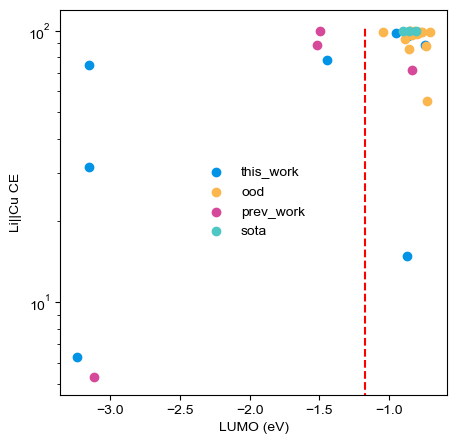

In [72]:
# Get unique values from the 'database' column
unique_databases = df_bind_all['database'][:-1].unique()

fig, ax = plt.subplots(figsize=(5, 5))
# Loop through each unique value and create a scatter plot
c = 0
for database in unique_databases:
    subset = df_bind_all[df_bind_all['database'] == database]
    ax.scatter(subset['LUMO_bound'], 100*subset['CE'], label=database, color=colors[c])  # Replace 'x_column' and 'y_column' with actual column names
    c += 1
# plt.title(f'Scatter Plot for {database}')
ax.vlines(x=df_bind_all['LUMO_bound'][-1:], ymin=0, ymax=103, color='red', linestyle='--')
ax.set_xlabel('LUMO (eV)')  # Replace with actual label
ax.set_ylabel('Li||Cu CE')  # Replace with actual label
# ax.set_ylim(0, 103)
ax.set_yscale('log')
plt.legend(frameon=False, loc='center')
plt.show()
# unique_databases

In [70]:
df_bind_all['LUMO_bound'][-1:]

KeyError: 0